# Deep models interpretability
This notebooks shows examples of approaches for interpretation of (pre-)trained model predictions.

In [1]:
%pip install scikit-image shap catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.9 MB/s eta 0:00:00


In [2]:
import urllib
import skimage
import torch, torch.nn as nn
import torch.nn.functional as F
import torchvision.models

import numpy as np
from skimage.transform import resize
import matplotlib.pyplot as plt
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

### please, don't remove the following line
x = torch.tensor([1], dtype=torch.float32).to(device)

device: cuda


In [3]:
import requests  # load imagenet class names
response = requests.get('https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json')
class_labels = {int(key): value for key, (code, value) in response.json().items()}
class_labels[897]

'washer'

### Task I: manual explanation with smoothgrad (2 points)

Let us begin by implementing our own little explainer for [DenseNet121](https://arxiv.org/abs/1608.06993) pretrained on ImageNet.

For the sake of simplicity, we're gonna rely on [SmoothGrad](https://arxiv.org/pdf/1706.03825.pdf) explainer - a simple average of gradients over noisy inputs.

In [4]:
model = torchvision.models.resnet50(pretrained=True).train(False).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


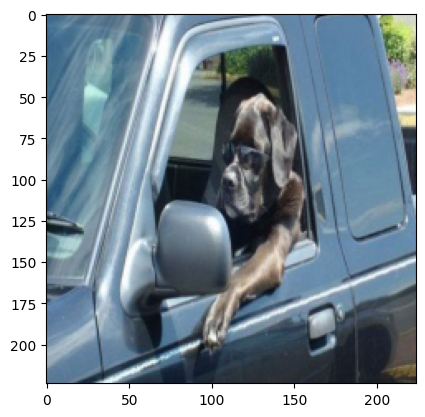

#1: p=0.853	bloodhound (163)
#2: p=0.039	washer (897)
#3: p=0.009	car_mirror (475)
#4: p=0.008	pickup (717)
#5: p=0.008	Weimaraner (178)
#6: p=0.007	Labrador_retriever (208)
#7: p=0.006	Chesapeake_Bay_retriever (209)
#8: p=0.005	limousine (627)
#9: p=0.004	pug (254)
#10: p=0.003	tub (876)


In [5]:
!wget -q https://cdn2.adrianflux.co.uk/wp-fluxposure/uploads/2014/08/no-7.jpg -O img.jpg

image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
plt.imshow(image)
plt.show()

with torch.no_grad():
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)
    probs = torch.softmax(model(image_tensor), dim=-1)[0]

for i, class_ix in enumerate(probs.argsort(descending=True)[:10]):
    print(f"#{i + 1}: p={probs[class_ix].item():.3f}\t{class_labels[class_ix.item()]} ({class_ix.item()})")

Now let's implement SmoothGrad itself.

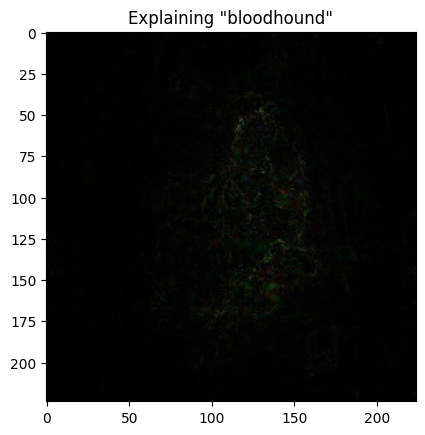

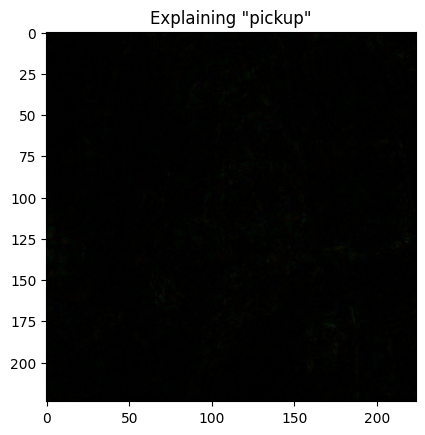

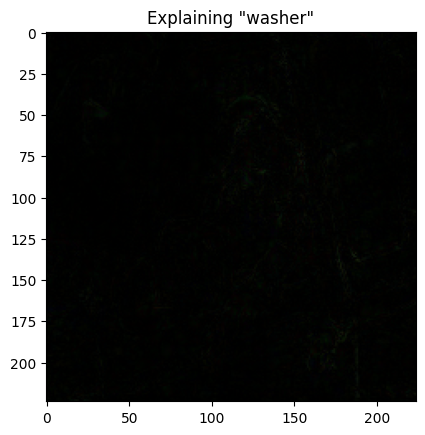

In [6]:
def explain_smoothgrad(image: torch.Tensor, class_ix, num_runs=32, sigma=0.1):
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)  # shape: [1, 3, h, w]
    image_tensor.requires_grad_(True)

    grads = []

    for _ in range(num_runs):
        noise = torch.randn_like(image_tensor) * sigma
        noisy_image = image_tensor + noise

        out = model(noisy_image)
        logit = out[0, class_ix]

        model.zero_grad()
        logit.backward(retain_graph=True)

        grads.append(image_tensor.grad.detach().clone())

        image_tensor.grad.zero_()

    average_gradients = torch.mean(torch.stack(grads), dim=0)[0]  # shape: [3, h, w]

    average_gradients = average_gradients.permute(1, 2, 0)

    assert tuple(average_gradients.shape) == image.shape
    return average_gradients.abs().cpu().numpy()


for class_ix in 163, 717, 897:  # <-- insert your classes here, use numbers in (brackets)
    plt.title(f'Explaining "{class_labels[class_ix]}"')
    plt.imshow(explain_smoothgrad(image, class_ix), cmap='gray')
    plt.show()

__Let's try it out!__ Peter Higgs nobel prize photo

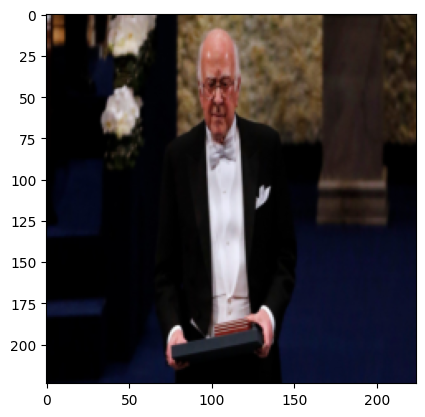

#1: p=0.211	suit (834)
#2: p=0.049	toilet_seat (861)
#3: p=0.040	plunger (731)
#4: p=0.032	vacuum (882)
#5: p=0.026	guillotine (583)
#6: p=0.024	balance_beam (416)
#7: p=0.023	academic_gown (400)
#8: p=0.022	torch (862)
#9: p=0.019	lab_coat (617)
#10: p=0.017	hook (600)


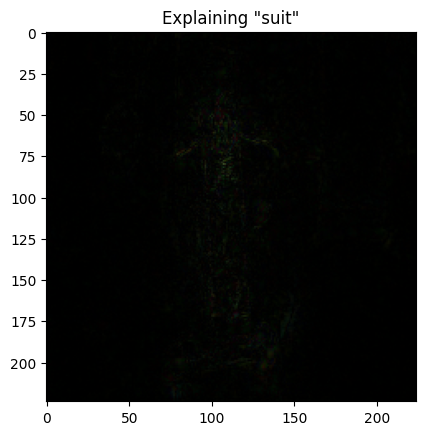

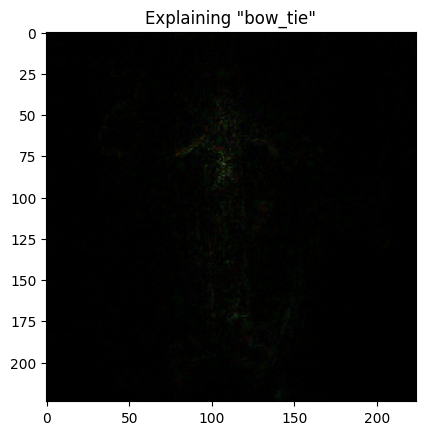

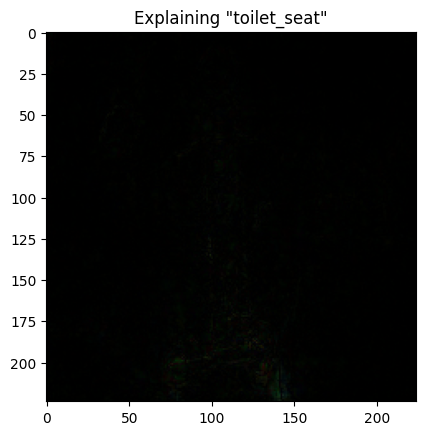

In [7]:
!wget -q https://i.pinimg.com/originals/3a/e1/83/3ae18369ab2e86be83e637ad702ec832.jpg -O img.jpg

image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
plt.imshow(image)
plt.show()

with torch.no_grad():
    image_tensor = torch.as_tensor(image, device=device, dtype=torch.float32)
    image_tensor = image_tensor[None].permute(0, 3, 1, 2)
    probs = torch.softmax(model(image_tensor), dim=-1)[0]

for i, class_ix in enumerate(probs.argsort(descending=True)[:10]):
    print(f"#{i + 1}: p={probs[class_ix].item():.3f}\t{class_labels[class_ix.item()]} ({class_ix.item()})")

for class_ix in 834, 457, 861:
    plt.title(f'Explaining "{class_labels[class_ix]}"')
    plt.imshow(explain_smoothgrad(image, class_ix), cmap='gray')
    plt.show()

### SHapley Additive exPlanations
Now, let's try something heavier. The current state of the art in explaining model predictions is [SHAP](https://arxiv.org/abs/1705.07874): Shapley Additive Explanations.

This method is based on [Shapley values](https://en.wikipedia.org/wiki/Shapley_value) - a game-theoretic concept that evaluates the contribution of individual players in a cooperative game. Except this time our "players" are input features and the "game" is predicting whichever output the model gave.

Computing Shapley values naively requires $O(F!)$ time where F is the number of features. To make this computation more feasible, authors [proposed](https://arxiv.org/abs/1705.07874) several approximations, one of which relies on averaged gradients. This approximation also requires "background" data - other images similar to the ones in question that can be used as reference points.

In [8]:
import shap
# load "background" images - some 50 random images from ImageNet used as "other data points" for SHAP
background, _ = shap.datasets.imagenet50()
background = torch.as_tensor(background / 255.0, device=device, dtype=torch.float32)
background = background.permute(0, 3, 1, 2)
background.size()

torch.Size([50, 3, 224, 224])

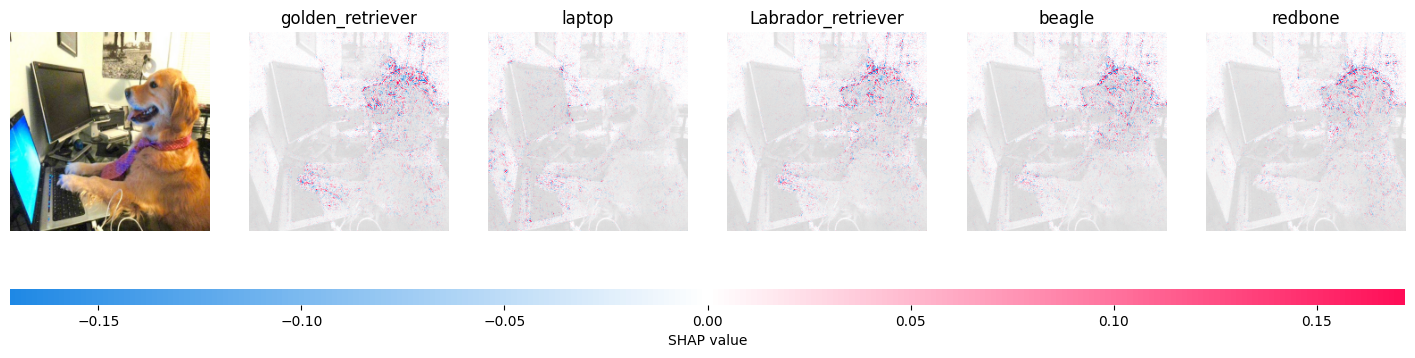

In [9]:
shap.initjs()  # run it before every (interactive) shap visualizer in colab
# v-- image to explain. If you're not using a GPU, this may take up to 20 minutes.
!wget -q https://i.pinimg.com/originals/32/da/5c/32da5c3314fcc5ebf1a7b7d1548fcb03.jpg -O img.jpg
image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
image_tensor = torch.as_tensor(image[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)
explainer = shap.GradientExplainer((model, model.conv1), background)
shap_values, indices = explainer.shap_values(image_tensor, ranked_outputs=5, nsamples=200)
shap.image_plot(shap_values=list(np.transpose(shap_values, (4, 0, 2, 3, 1))),
                pixel_values=image_tensor.permute(0, 2, 3, 1).cpu().numpy(),
                labels=np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy()))

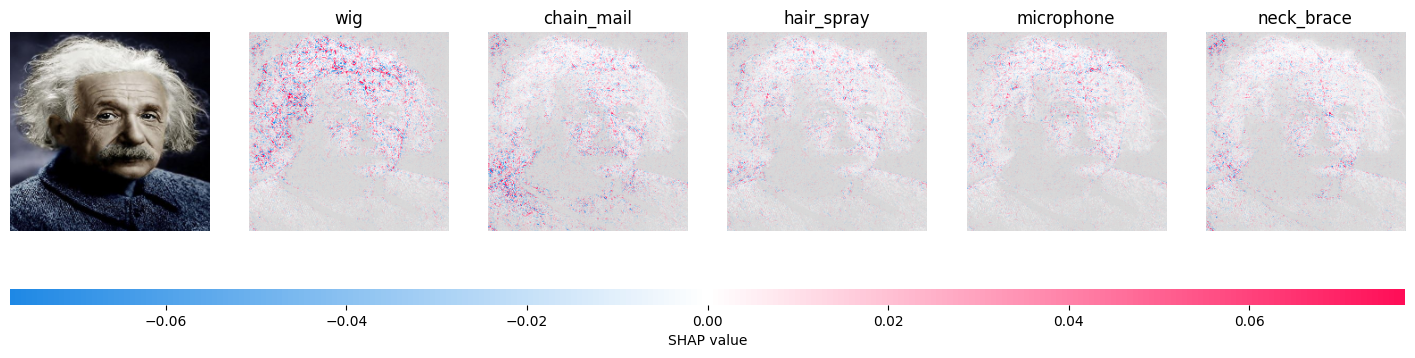

In [10]:
shap.initjs() # obligatory physicist reference
!wget -q https://images-na.ssl-images-amazon.com/images/I/51ArQaCkkZL._AC_.jpg -O img.jpg
image = resize(plt.imread('img.jpg')[..., :3] / 255.0, (224, 224))
image_tensor = torch.as_tensor(image[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)
explainer = shap.GradientExplainer((model, model.conv1), background)
shap_values, indices = explainer.shap_values(image_tensor, ranked_outputs=5, nsamples=200)
shap.image_plot(shap_values=list(np.transpose(shap_values, (4, 0, 2, 3, 1))),
                pixel_values=image_tensor.permute(0, 2, 3, 1).cpu().numpy(),
                labels=np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy()))

###### Explaining classical machine learning models

Finally, let's see how SHAP explainers can be applied to more conventional machine learning models like gradient boosting.

Spoiler: exactly the same from a user's perspective. However, this time we're gonna use a different Shapley approximation implemented in TreeExplainer. For a full set of available explainers, take a look at their official [examples page](https://github.com/slundberg/shap/tree/master/notebooks).

**NB: the following cells requires JavaScript support and should work in Jupyter (not JupyterLab or cocalc)**.
In that case try running it on Google colab: https://colab.research.google.com/github/yandexdataschool/mlhep2020-assignments/blob/master/notebooks/interpretability/interpretability_demo.ipynb

In [11]:
import catboost # pip install catboost
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing(as_frame=True)
X, y = california.data, california.target.values
ensemble = catboost.CatBoostRegressor(iterations=100, learning_rate=0.1)
ensemble.fit(X, y, verbose=False, plot=False)
explainer = shap.TreeExplainer(ensemble)
shap_values = explainer.shap_values(X)

shap.initjs() # visualize explanation of the first example
shap.force_plot(explainer.expected_value, shap_values[0, :], X.iloc[0, :])

In [12]:
# Explain training data: each *column* is a rotated plot from above, stacked for all training samples
shap.initjs() # (this plot is interactive, hover mouse to see feature names)
shap.force_plot(explainer.expected_value, shap_values[::100], X[::100])

### Task II: Explain Intermediate Layers of Resnet50 on ImageNet (3 points)

Sometimes, computing explanations w.r.t. pixels is more difficult (and less interpretable) than using intermediate layers that are closer to the "output" layer. The trick is to compute low-resolution explanations of output w.r.t. intermediate layer and then resizing them to fit the original image.

Each layer in deep CNN learns filters of increasing complexity. The first layers learn basic feature detection filters such as edges and corners. The middle layers learn filters that detect parts of objects — for faces, they might learn to respond to features like eyes and brows, and deeper layers capture entire objects.

**Your task** is to explain ResNet50 model outputs with respect to the convolution module from 1st, 2nd, 3rd and 4th layer of the pretrained Resnet50 network using the same GradientExplainer. *The task may require some googling or browsing the [docs](https://shap.readthedocs.io/en/latest) :)* A good starting point is from [this example](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Explain%20an%20Intermediate%20Layer%20of%20VGG16%20on%20ImageNet%20%28PyTorch%29.html), but for ResNet50 and on different images.

**Please use at least 10 images from across the internet (or from ImageNet) and compare the 2nd and 4th layer explanations on these images.**


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[1] Top predicted class: window_screen
  Explaining layer2 for window_screen...


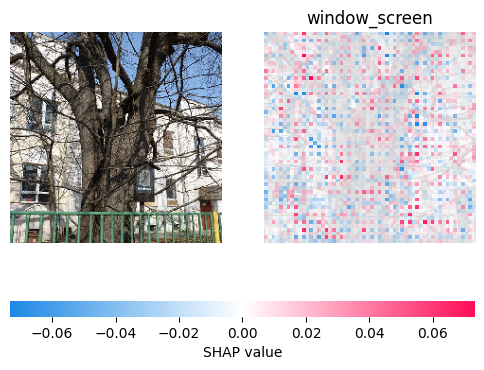

  Explaining layer4 for window_screen...


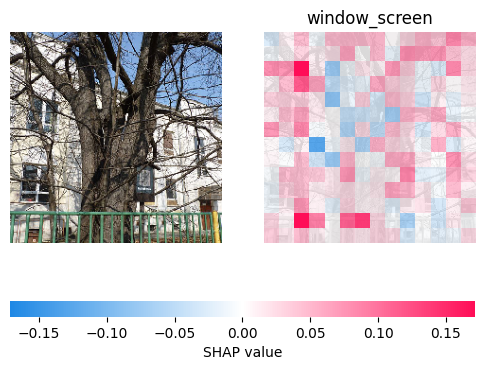

[2] Top predicted class: American_egret
  Explaining layer2 for American_egret...


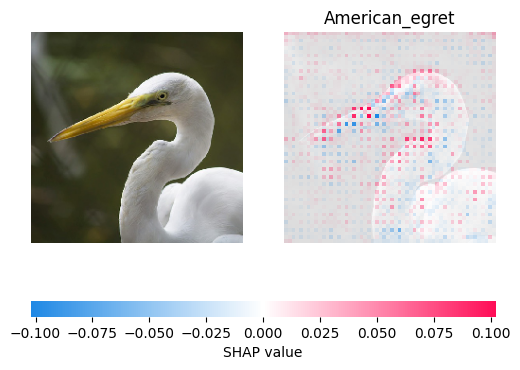

  Explaining layer4 for American_egret...


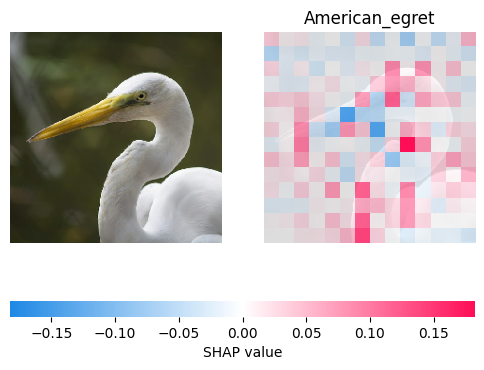

[3] Top predicted class: speedboat
  Explaining layer2 for speedboat...


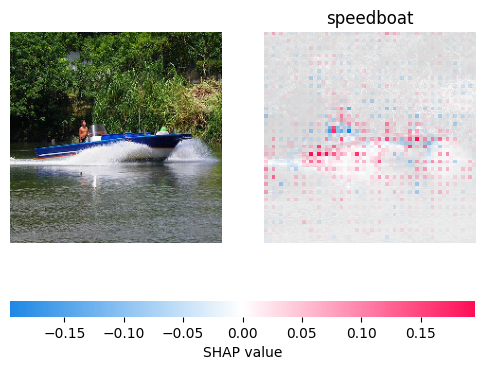

  Explaining layer4 for speedboat...


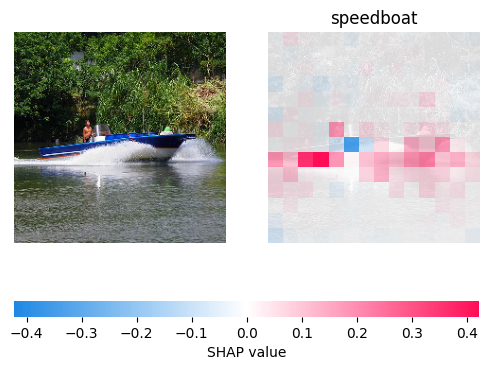

[4] Top predicted class: puck
  Explaining layer2 for puck...


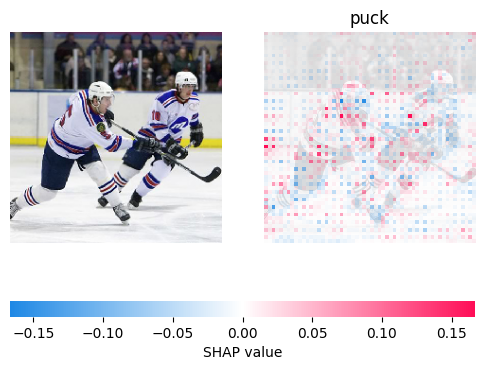

  Explaining layer4 for puck...


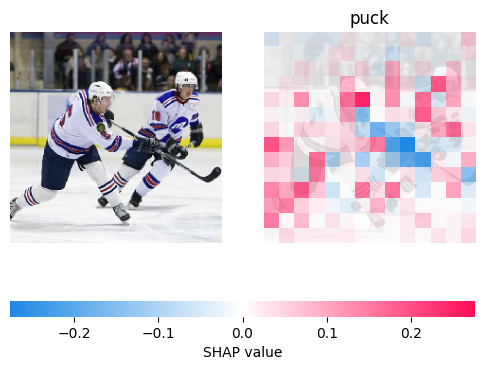

[5] Top predicted class: handkerchief
  Explaining layer2 for handkerchief...


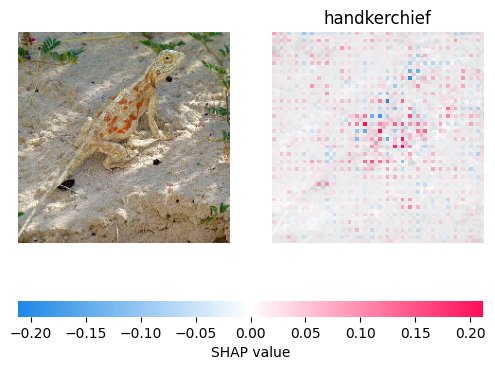

  Explaining layer4 for handkerchief...


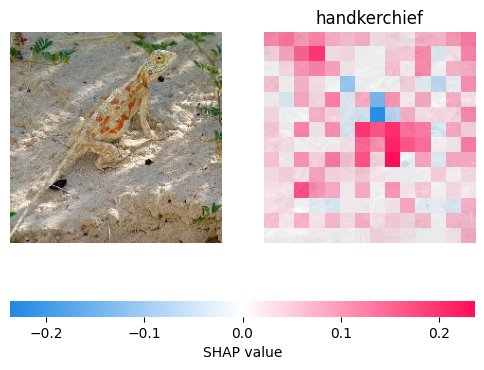

[6] Top predicted class: dishwasher
  Explaining layer2 for dishwasher...


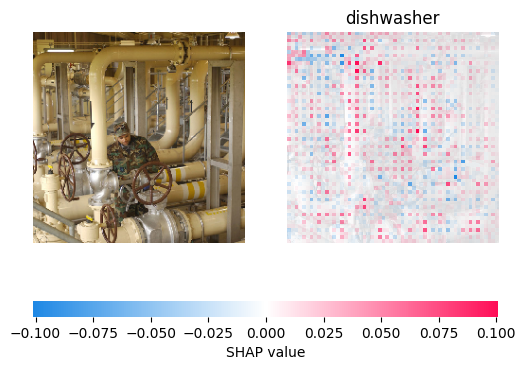

  Explaining layer4 for dishwasher...


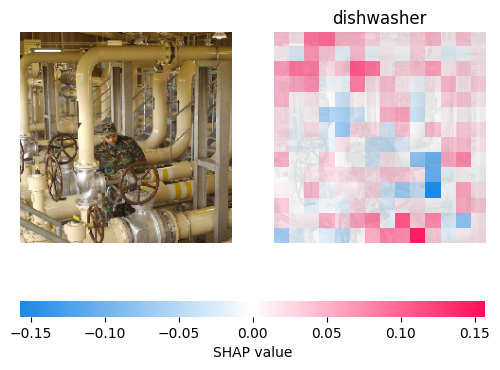

[7] Top predicted class: broccoli
  Explaining layer2 for broccoli...


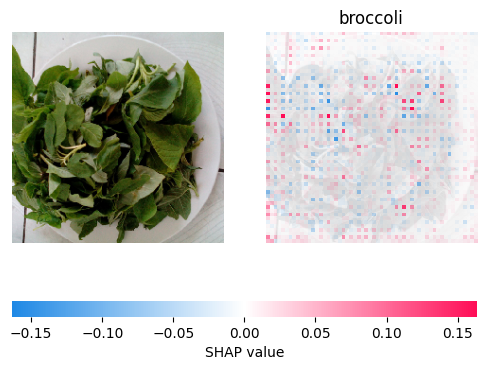

  Explaining layer4 for broccoli...


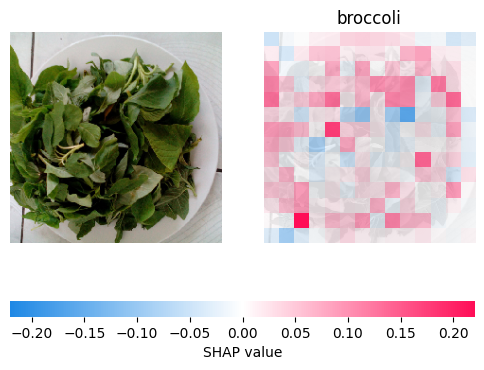

[8] Top predicted class: sombrero
  Explaining layer2 for sombrero...


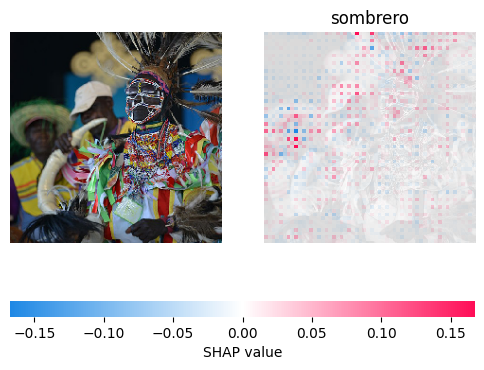

  Explaining layer4 for sombrero...


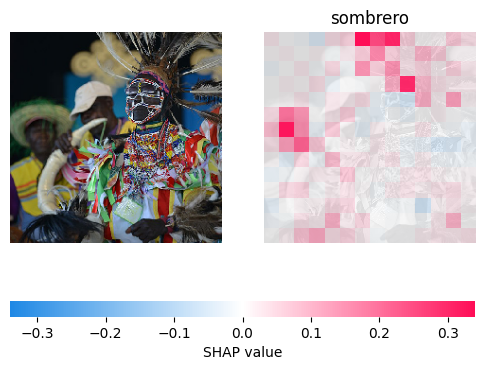

[9] Top predicted class: studio_couch
  Explaining layer2 for studio_couch...


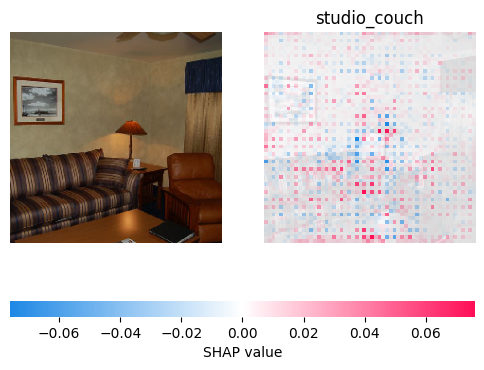

  Explaining layer4 for studio_couch...


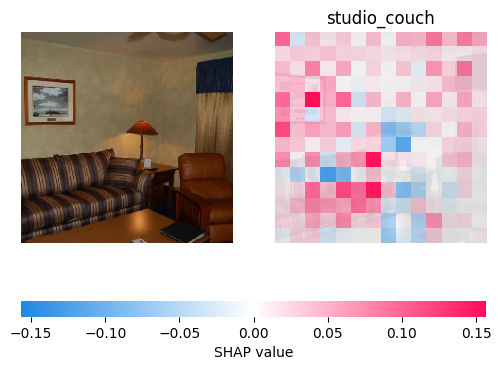

[10] Top predicted class: promontory
  Explaining layer2 for promontory...


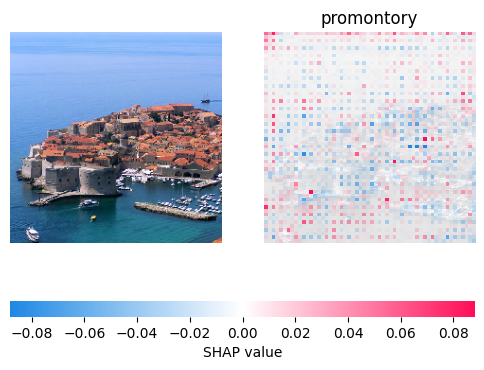

  Explaining layer4 for promontory...


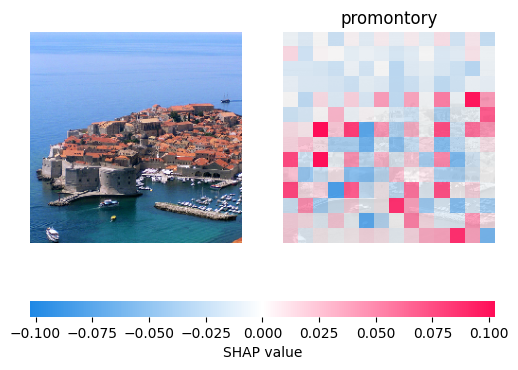

In [13]:
import shap, torch
import matplotlib.pyplot as plt
import numpy as np

model = torchvision.models.resnet50(pretrained=True).eval().to(device)

images, labels = shap.datasets.imagenet50()
images = images / 255.0  # normalize to [0,1]
labels = np.array(labels)

background_imgs = images[10:]   # 40 images for background
test_imgs = images[:10]         # first 10 for explanation

background = torch.as_tensor(background_imgs, device=device, dtype=torch.float32).permute(0, 3, 1, 2)


layers = {
    "layer2": model.layer2,
    "layer4": model.layer4
}

for i, img in enumerate(test_imgs):
    image_tensor = torch.as_tensor(img[None], device=device, dtype=torch.float32).permute(0, 3, 1, 2)

    # Predict top class
    with torch.no_grad():
        probs = torch.softmax(model(image_tensor), dim=-1)[0]
        top_class = int(probs.argmax())
        class_name = class_labels[top_class]
        print(f"[{i+1}] Top predicted class: {class_name}")

    # Compare explanations for layer2 and layer4
    for layer_name in ["layer2", "layer4"]:
        print(f"  Explaining {layer_name} for {class_name}...")
        explainer = shap.GradientExplainer((model, layers[layer_name]), background)
        shap_values, indices = explainer.shap_values(image_tensor, ranked_outputs=1, nsamples=100)

        # prepare data for plotting
        shap_values = np.transpose(shap_values, (4, 0, 2, 3, 1))
        labels_np = np.vectorize(lambda i: class_labels[i])(indices.cpu().numpy())

        # visualize shap maps
        shap.image_plot(
            shap_values=list(shap_values),
            pixel_values=image_tensor.permute(0, 2, 3, 1).cpu().numpy(),
            labels=labels_np
        )


Исследовать, как уровень абстракции признаков изменяется от ранних к поздним слоям сети ResNet-50.  
Для этого применён `shap.GradientExplainer` к промежуточным слоям `layer2` и `layer4` модели, обученной на ImageNet.  
В качестве тестовых изображений использованы первые 10 примеров из датасета `imagenet50`;  
оставшиеся 40 изображений использовались как фоновые («background») данные.



Для каждого изображения из тестовой выборки были вычислены карты SHAP-значений:
- **Layer 2** — ранний свёрточный блок (низкоуровневые фильтры: контуры, текстуры, цвета);  
- **Layer 4** — глубокий блок (высокоуровневые признаки: целостные объекты, их части).  

SHAP-значения интерпретируются следующим образом:
- красные области — пиксели/фичи, увеличивающие вероятность предсказанного класса;  
- синие области — пиксели, уменьшающие уверенность модели.



| Пример | Layer 2 | Layer 4 |
|:--|:--|:--|
| Window screen | Реагирует на контуры ветвей и текстуру фона | Концентрируется на оконных рамах — структурных частях объекта |
| American egret | Активации вдоль границ пера и клюва | Фокус на голове и клюве — семантически значимая часть |
| Speedboat | Разрозненные активации на воде и брызгах | Локализованные области на корпусе катера — объект целиком |
| Puck | Реагирует на игроков и лед, фон детализирован | Основные активации только на игроках и шайбе |
| Lizard | Паттерны на песке и теле | Чёткие пятна по контурy ящерицы, фон игнорируется |


### Вывод

- На раннем слое `layer2` модель выделяет **низкоуровневые признаки** — контуры, цвета, текстуры.  
- На позднем `layer4` SHAP-карты отражают **высокоуровневые семантические структуры** — целые объекты или их ключевые части.  
- По мере продвижения сигнала через сеть ResNet-50 уровень абстракции представлений растёт:  
  сеть переходит от фильтров краёв к распознаванию форм и объектов.  



## References

* SHAP explainer based on superpixels - [notebook](https://slundberg.github.io/shap/notebooks/ImageNet%20VGG16%20Model%20with%20Keras.html)
* SHAP reference notebook - [view on github](https://github.com/slundberg/shap/tree/master/notebooks)
* More various explainers in [ELI5](https://github.com/TeamHG-Memex/eli5)
* Same notebook on Google [Colab](https://colab.research.google.com/github/yandexdataschool/mlhep2020-assignments/blob/master/notebooks/interpretability/interpretability_demo.ipynb)